In [6]:
!pip install opencv-python imutils

In [7]:
!pip install keyboard matplotlib

No gun detected for 30 seconds, stopping camera.


In [3]:
import pyttsx3

# Initialize the TTS engine
engine = pyttsx3.init()

# Text you want to convert to speech
text = "Hello, this is an offline text to speech conversion example."

# Convert the text to speech
engine.say(text)

# Play the speech
engine.runAndWait()


Security Threat!!


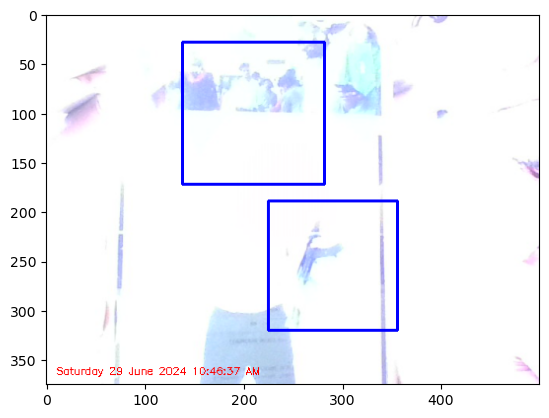

In [3]:
import numpy as np
import cv2
import imutils
import datetime
import matplotlib.pyplot as plt
import pyttsx3
import keyboard
import time

engine = pyttsx3.init()# text to speech
engine2 = pyttsx3.init()
gun_cascade = cv2.CascadeClassifier('cascade.xml')  # for gun detection
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')  # for face detection

camera = cv2.VideoCapture(0)
firstFrame = None
gun_exist = False
no_gun_start_time = None  # To track the time when no gun is detected

while True:
    ret, frame = camera.read()
    if not ret or frame is None:
        break

    frame = imutils.resize(frame, width=500)
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # to Check gun and face frame by frame
    gun = gun_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=20, minSize=(100, 100))
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    if len(gun) > 0:
        gun_exist = True
        no_gun_start_time = None  # Reset the timer if a gun is detected
    else:
        if no_gun_start_time is None:
            no_gun_start_time = time.time()  # Start the timer
        gun_exist = False

    for (x, y, w, h) in gun:  # Frame for the gun
        frame = cv2.rectangle(frame, (x, y), (x + w, y + h), (255, 0, 0), 2)
        roi_gray = gray[y:y + h, x:x + w]
        roi_color = frame[y:y + h, x:x + w]
    for (x, y, w, h) in faces:
        frame = cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(frame, "Face Detected", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)

    if firstFrame is None:
        firstFrame = gray
        continue

    # To put date, day and time
    cv2.putText(frame, datetime.datetime.now().strftime("%A %d %B %Y %I:%M:%S %p"),
                (10, frame.shape[0] - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.35, (0, 0, 255), 1)

    if gun_exist:
        print("Security Threat!!")
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        plt.show()
        while True:
            engine.setProperty('voice',
                               'HKEY_LOCAL_MACHINE\SOFTWARE\Microsoft\Speech\Voices\Tokens\TTS_MS_EN-US_ZIRA_11.0')
            engine.say("Firearms detected, Security at threat")
            engine.runAndWait()

            time.sleep(1)

            if keyboard.is_pressed('enter'):
                break

        break
    else:
        cv2.putText(frame, "No Gun Detected", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (0, 255, 0), 2)
        cv2.imshow("Camera Capture", frame)

        # Check if no gun has been detected for more than 10 seconds
        if no_gun_start_time is not None and (time.time() - no_gun_start_time) > 10:
            print("No gun detected, stopping camera.")
            #engine2.setProperty('voice','HKEY_LOCAL_MACHINE\SOFTWARE\Microsoft\Speech\Voices\Tokens\TTS_MS_EN-US_ZIRA_11.0')
            #engine2.say("no firearms detected")
            #engine2.runAndWait()
            break

    key = cv2.waitKey(1) & 0xFF  # 0xFF ensures compatibility of 8 bits
    if key == ord('q'):  # ord gives unicode of a character
        break

camera.release()
cv2.destroyAllWindows()  # Closes all cv2 files
